In [26]:
# Importing the libraries
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('classic')
%matplotlib inline

from IPython.display import HTML

import os

sns.set()

In [27]:
# Quantile Function Definitions
def q1(x):
    return x.quantile(0.28)

def q2(x):
    return x.median()

def q3(x):
    return x.quantile(0.72)

In [28]:
station_name = '980'
input_folder = os.path.join('../stations/data', f'{station_name}.csv')
DISCHARGE_DAILY = pd.read_csv(input_folder,parse_dates=['Fecha'],index_col="Fecha",dayfirst=True,na_values="NA")

In [29]:
# Identify the missing data
DISCHARGE_DAILY_date_missing = pd.date_range(start = DISCHARGE_DAILY.index[0].strftime('%Y-%m-%d'), end = DISCHARGE_DAILY.index[-1].strftime('%Y-%m-%d'),freq='D')
# Re-index the dataframe based on the missind date variable
DISCHARGE_DAILY = DISCHARGE_DAILY.reindex(DISCHARGE_DAILY_date_missing,fill_value=None)
# Set index Fecha
DISCHARGE_DAILY.index.name = 'Date' 
# Change columns names
DISCHARGE_DAILY.columns = ['Discharge']
# Print the last 6 values
HTML(DISCHARGE_DAILY.tail(6).to_html())

,Discharge
Date,
2026-08-27,4.99
2026-08-28,5.08
2026-08-29,5.12
2026-08-30,5.17
2026-08-31,5.20
2026-09-01,5.22


In [30]:
# group the Dataframe in a monthly time scale
GROUPER_DISCHARGE_MONTHLY = DISCHARGE_DAILY.groupby(pd.Grouper(freq='1MS'))
NUMBER_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1)
# sum the number of null values and assing a "true" if the number of null values are lower that a number for a given month
BOOL_MISSING = GROUPER_DISCHARGE_MONTHLY.apply(lambda x: pd.isnull(x).sum()).unstack(1) < 5
BOOL_MISSING = BOOL_MISSING.to_frame() # convert to DataFrame
BOOL_MISSING.columns = ['missing'] # change the column name to "missing"

NUMBER_MISSING = NUMBER_MISSING.to_frame()
NUMBER_MISSING.columns = ['number_missing'] # change the column name to "missing"

In [31]:
DISCHARGE_MONTHLY = DISCHARGE_DAILY.resample('M').apply(lambda x: x.mean() if x.isnull().sum() < 5 else np.nan)
DISCHARGE_MONTHLY['Year'] = DISCHARGE_MONTHLY.index.year
DISCHARGE_MONTHLY['Month'] = DISCHARGE_MONTHLY.index.month
DISCHARGE_MONTHLY['water_year'] = DISCHARGE_MONTHLY.index.year.where(DISCHARGE_MONTHLY.index.month < 4, DISCHARGE_MONTHLY.index.year + 1)

## create column for day, month, year in the daily discharge ()
DISCHARGE_DAILY['Year'] = DISCHARGE_DAILY.index.year
DISCHARGE_DAILY['Month'] = DISCHARGE_DAILY.index.month
DISCHARGE_DAILY['Day'] = DISCHARGE_DAILY.index.day
DISCHARGE_DAILY['monthday'] = DISCHARGE_DAILY.index.day_of_year
DISCHARGE_DAILY['water_year'] = DISCHARGE_DAILY.index.year.where(DISCHARGE_DAILY.index.month < 4, DISCHARGE_DAILY.index.year + 1)
## 
HTML(DISCHARGE_DAILY.head(18).to_html(index=False))
# DISCHARGE_MONTHLY.to_clipboard()

Discharge,Year,Month,Day,monthday,water_year
3.25,1980,1,1,1,1980
3.22,1980,1,2,2,1980
3.20,1980,1,3,3,1980
3.24,1980,1,4,4,1980
3.21,1980,1,5,5,1980
3.20,1980,1,6,6,1980
3.20,1980,1,7,7,1980
3.20,1980,1,8,8,1980
3.20,1980,1,9,9,1980
3.18,1980,1,10,10,1980


In [32]:
YEAR_SELECTED = np.unique(DISCHARGE_DAILY['Year'])
DISCHARGE_DAILY_PIVOT = pd.pivot_table(DISCHARGE_DAILY,index=['monthday'],columns=['Year'], values=['Discharge'],dropna=False)
DISCHARGE_DAILY_PIVOT.columns = YEAR_SELECTED

In [33]:
HTML(DISCHARGE_DAILY_PIVOT.tail(5).to_html())

,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
monthday,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
362,3.60,3.41,3.95,4.75,4.20,3.31,4.55,3.85,2.47,2.03,3.18,3.70,2.95,3.45,3.40,3.00,2.39,3.75,3.7,2.50,3.70,4.56,5.09,4.06,2.52,3.02,2.39,3.49,2.42,4.33,2.90,2.64,2.57,3.39,4.32,4.08,3.31,3.34,3.37,4.27,2.36,2.64,2.23,NaN,NaN,NaN,NaN
363,3.60,3.40,3.95,4.71,4.16,3.30,4.51,3.85,2.47,2.05,3.20,3.70,2.90,3.45,3.40,2.90,2.37,3.85,3.7,2.48,3.68,4.54,5.10,4.00,2.52,2.98,2.38,3.47,2.37,4.32,2.89,2.63,2.56,3.37,4.29,4.09,3.30,3.33,3.36,4.26,2.36,2.65,2.24,NaN,NaN,NaN,NaN
364,3.60,3.40,3.91,4.74,4.15,3.30,4.50,3.85,2.47,2.12,3.22,3.67,2.89,3.45,3.38,2.85,2.34,3.86,3.7,2.41,3.67,4.51,5.13,NaN,2.52,2.96,2.40,3.46,2.44,4.33,2.90,2.65,2.52,3.36,4.27,4.10,3.30,3.30,3.35,4.24,2.30,2.66,2.21,NaN,NaN,NaN,NaN
365,3.56,3.36,3.90,4.75,4.11,3.26,4.50,3.81,2.47,2.11,3.19,3.70,2.81,3.45,3.35,2.85,2.30,3.99,3.7,2.38,3.67,4.48,5.11,NaN,2.52,2.95,2.38,3.46,2.34,4.31,2.87,2.68,2.53,3.41,4.26,4.09,3.30,3.29,3.33,4.21,2.28,2.65,2.23,NaN,NaN,NaN,NaN
366,3.55,NaN,NaN,NaN,4.10,NaN,NaN,NaN,2.47,NaN,NaN,NaN,2.80,NaN,NaN,NaN,2.30,NaN,NaN,NaN,3.63,NaN,NaN,NaN,2.49,NaN,NaN,NaN,2.35,NaN,NaN,NaN,2.55,NaN,NaN,NaN,3.28,NaN,NaN,NaN,2.26,NaN,NaN,NaN,NaN,NaN,NaN


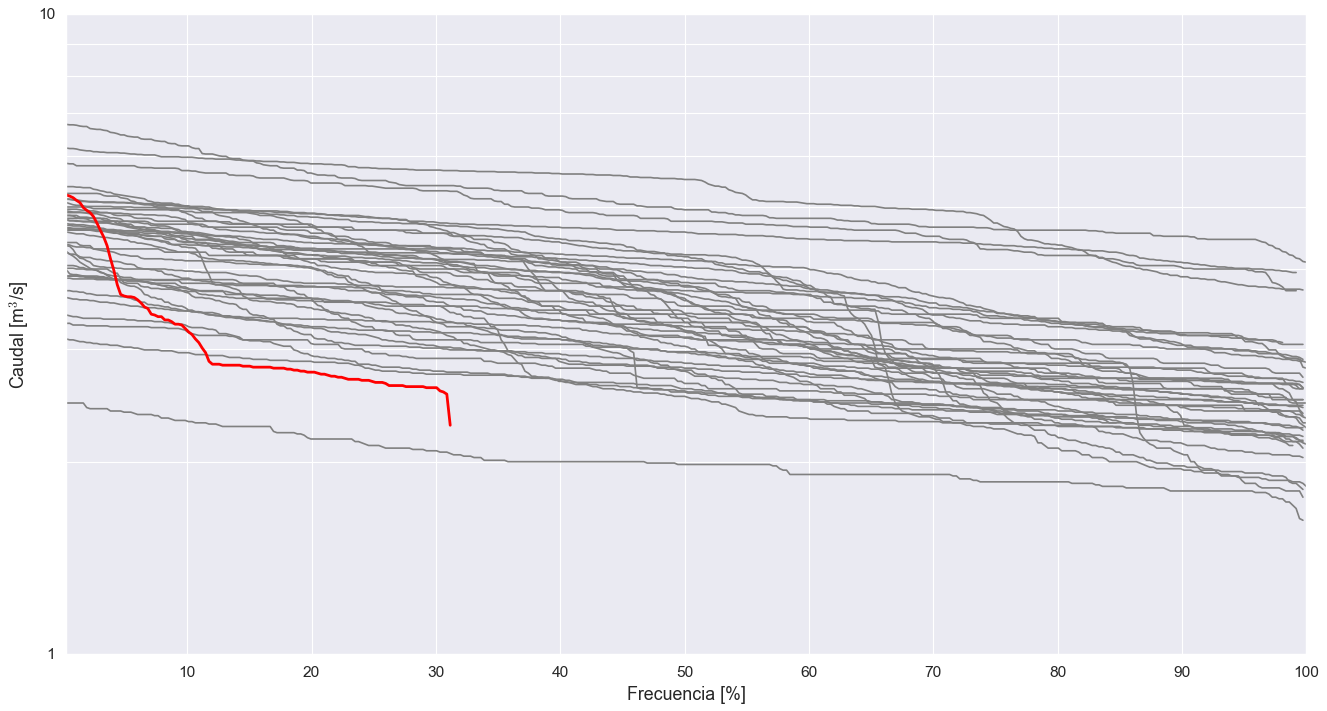

In [34]:
plt.figure(figsize=(20, 10))
df_sorted = pd.DataFrame()

for column in DISCHARGE_DAILY_PIVOT.columns:
    sorted_column = DISCHARGE_DAILY_PIVOT[column].sort_values(ascending=False)
    df_sorted[column] = sorted_column
    DISCHARGE_DAILY_PIVOT[column] = np.arange(1., len(sorted_column) + 1) / len(sorted_column)
    pct_nan = (np.sum(np.isnan(sorted_column))/len(sorted_column))*100
    if pct_nan < 20:
        plt.plot(DISCHARGE_DAILY_PIVOT[column]*100, sorted_column,color='gray')
        plt.yscale('log')  # Set y-axis to logarithmic scale
    else:
        continue


plt.xticks([0,10,20,30,40,50,60,70,80,90,100],labels=['0','10','20','30','40','50','60','70','80','90','100']);
plt.xlabel('Frecuencia [%]',fontsize=16);
plt.ylabel('Caudal [m$^3$/s]',fontsize=16);
 
year_selected = 2026
plt.plot(DISCHARGE_DAILY_PIVOT[year_selected]*100,df_sorted[year_selected].sort_values(ascending=False),color='red',linewidth=2.5)
# plt.plot(DISCHARGE_DAILY_PIVOT.iloc[:, -1]*100, sorted_column,color='red');

import matplotlib.ticker as ticker
def myLogFormat(y,pos):
    # Find the number of decimal places required
    decimalplaces = int(np.maximum(-np.log10(y),0))     # =0 for numbers >=1
    # Insert that number into a format string
    formatstring = '{{:.{:1d}f}}'.format(decimalplaces)
    # Return the formatted tick label
    return formatstring.format(y)

y_axis = plt.gca().yaxis
y_axis.set_major_formatter(ticker.FuncFormatter(myLogFormat))

# Adjust the font size for tick labels on both axes
plt.grid(True,'major')
plt.grid(True,'minor')
plt.xticks(fontsize=14);
plt.yticks(fontsize=14);

